# [Deep Agents - Middleware](https://docs.langchain.com/oss/python/deepagents/middleware)


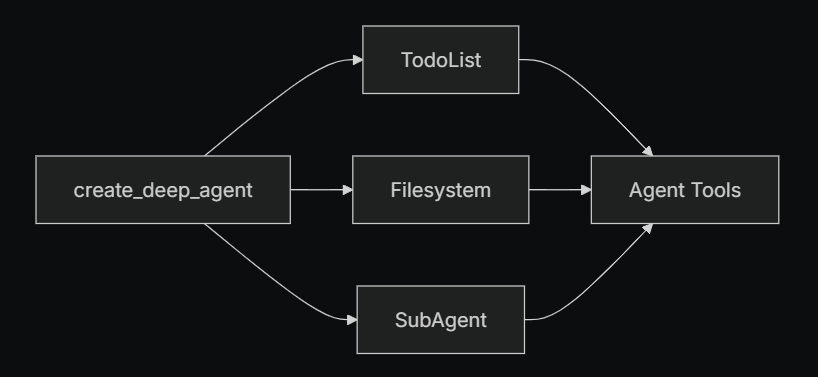

## 1. Middleware란 무엇인가?

### 📌 Middleware의 역할

**Middleware**는 Agent의 실행 파이프라인에 끼어들어 동작을 수정하거나 확장하는 컴포넌트입니다.

#### 왜 Middleware가 필요한가?

Middleware를 통해:
- ✅ Agent의 입출력을 가로채고 수정
- ✅ 로깅, 모니터링, 디버깅 기능 추가
- ✅ 보안, 검증, 필터링 로직 삽입
- ✅ 재사용 가능한 기능 모듈화

### Deep Agents의 Middleware 구조

Deep Agents는 다음과 같은 계층적 Middleware 구조를 사용합니다:

```
User Input
    ↓
[TodoListMiddleware] - 작업 목록 관리
    ↓
[FilesystemMiddleware] - 파일 시스템 접근
    ↓
[SubAgentMiddleware] - Subagent 위임
    ↓
[CustomMiddleware] - 사용자 정의 기능
    ↓
Core Agent Logic
    ↓
Response
```


## 2. 환경 설정


In [ ]:
# 필요한 패키지 설치
%pip install -q deepagents tavily-python


In [ ]:
# 환경 변수 설정
import os
from getpass import getpass

if "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass("Anthropic API Key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass("Tavily API Key: ")


## 3. 내장 Middleware: TodoList

TodoListMiddleware는 Agent가 작업 목록을 관리할 수 있게 합니다.


In [ ]:
from deepagents import create_agent

# TodoList 기능이 포함된 Agent
todo_agent = create_agent(
    model="claude-3-5-sonnet-20241022",
    system_prompt="""
    당신은 프로젝트 관리 어시스턴트입니다.
    작업을 받으면:
    1. 작업을 단계별로 분해합니다
    2. Todo 목록을 만들고 관리합니다
    3. 각 단계를 순차적으로 실행합니다
    4. 완료된 작업을 체크합니다
    """
)

# 복잡한 작업 요청
complex_task = """
웹사이트 개발 프로젝트를 시작하려고 합니다.
다음 작업들을 계획하고 실행해주세요:

1. 프로젝트 구조 설계
2. 필요한 기술 스택 조사
3. 데이터베이스 스키마 설계
4. API 엔드포인트 정의
5. 프론트엔드 와이어프레임 작성

각 작업을 Todo 목록으로 관리하면서 진행해주세요.
"""

response = todo_agent.invoke(
    {"messages": [{"role": "user", "content": complex_task}]},
    config={"configurable": {"thread_id": "todo-demo"}}
)

print("✅ Todo 관리 결과:")
print(response["messages"][-1].content)


In [ ]:
# 파일 시스템 기능을 가진 Agent
file_agent = create_agent(
    model="claude-3-5-sonnet-20241022",
    system_prompt="""
    당신은 파일 관리 전문가입니다.
    사용자의 요청에 따라 파일과 폴더를 생성, 읽기, 수정, 삭제할 수 있습니다.
    모든 작업 후 결과를 명확히 보고하세요.
    """
)

# 파일 시스템 작업
file_task = """
다음과 같은 프로젝트 구조를 만들어주세요:

project/
├── README.md (프로젝트 설명 포함)
├── src/
│   ├── main.py (Hello World 코드)
│   └── utils.py (유틸리티 함수 스켈레톤)
├── tests/
│   └── test_main.py (기본 테스트)
└── requirements.txt (필요한 패키지 목록)

모든 파일에 적절한 초기 내용을 작성해주세요.
"""

response = file_agent.invoke(
    {"messages": [{"role": "user", "content": file_task}]},
    config={"configurable": {"thread_id": "file-demo"}}
)

print("✅ 파일 시스템 작업 결과:")
print(response["messages"][-1].content[:500])


In [ ]:
# 상세한 System Prompt를 가진 전문 Agent
expert_agent = create_agent(
    model="claude-3-5-sonnet-20241022",
    system_prompt="""
    # 역할
    당신은 시니어 소프트웨어 아키텍트이자 기술 컨설턴트입니다.
    
    # 핵심 원칙
    1. **분석 우선**: 요청을 받으면 먼저 요구사항을 철저히 분석합니다
    2. **최선의 실무**: 업계 표준과 베스트 프랙티스를 따릅니다
    3. **명확한 설명**: 기술적 결정의 이유를 설명합니다
    4. **실용적 접근**: 이론과 실무의 균형을 맞춥니다
    
    # 작업 프로세스
    1. 요구사항 확인 및 질문 (필요시)
    2. 솔루션 옵션 검토
    3. 추천 솔루션 제시 (장단점 포함)
    4. 구현 계획 수립
    5. 위험 요소 및 고려사항 제시
    
    # 출력 형식
    - 구조화된 마크다운 사용
    - 코드 예제는 주석과 함께
    - 의사결정 트리나 다이어그램 (필요시)
    
    # 제약사항
    - 확실하지 않은 정보는 가정임을 명시
    - 보안과 성능을 항상 고려
    - 확장 가능하고 유지보수 가능한 솔루션 선호
    """
)

# 기술 자문 요청
consultation = """
마이크로서비스 아키텍처로 전환을 고려 중입니다.
현재는 모놀리식 Django 애플리케이션이고, 
약 100만 명의 사용자가 있습니다.

전환 여부와 접근 방법에 대해 자문해주세요.
"""

response = expert_agent.invoke(
    {"messages": [{"role": "user", "content": consultation}]},
    config={"configurable": {"thread_id": "expert-consultation"}}
)

print("🎓 전문가 자문:")
print("="*60)
print(response["messages"][-1].content)
print("="*60)


## 6. Human-in-the-Loop (HITL)

중요한 결정이나 작업 전에 사람의 승인을 받도록 설정할 수 있습니다.


In [ ]:
# Human-in-the-loop 설정이 있는 Agent
hitl_agent = create_agent(
    model="claude-3-5-sonnet-20241022",
    system_prompt="""
    당신은 시스템 관리자 어시스턴트입니다.
    중요한 작업(파일 삭제, 시스템 변경 등)을 수행하기 전에
    항상 사용자의 확인을 받아야 합니다.
    """,
    # interrupt_before=["action"]  # 특정 노드 실행 전 중단
)

print("⚠️ Human-in-the-Loop 데모")
print("="*60)
print("""
HITL은 다음과 같은 시나리오에서 유용합니다:

1. 파일 삭제나 수정 전 확인
2. 외부 API 호출 전 승인
3. 비용이 발생하는 작업 전 검토
4. 중요한 의사결정 시점

Agent가 중단점에 도달하면:
- 사용자에게 현재 상태를 보여줌
- 승인 또는 수정을 기다림
- 승인 후 계속 진행

예제 코드:
```python
# Agent 실행
result = agent.invoke(input, config=config)

# 중단점 확인
if result.next:
    # 사용자 승인 대기
    user_approval = input("계속 진행하시겠습니까? (y/n): ")
    
    if user_approval.lower() == 'y':
        # 승인 후 재개
        result = agent.invoke(None, config=config)
```
""")
print("="*60)


## 7. 커스텀 Middleware 만들기

자신만의 Middleware를 만들어 Agent의 동작을 확장할 수 있습니다.


In [ ]:
# 로깅 Middleware 예제
from datetime import datetime

class LoggingMiddleware:
    """Agent의 모든 입출력을 로깅하는 Middleware"""
    
    def __init__(self, log_file="agent_log.txt"):
        self.log_file = log_file
    
    def log(self, message, level="INFO"):
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        log_entry = f"[{timestamp}] [{level}] {message}\n"
        
        with open(self.log_file, "a", encoding="utf-8") as f:
            f.write(log_entry)
        
        print(log_entry.strip())
    
    def on_input(self, input_data):
        """입력 시점에 호출"""
        self.log(f"사용자 입력: {input_data.get('messages', [])[-1].get('content', '')[:100]}")
        return input_data
    
    def on_output(self, output_data):
        """출력 시점에 호출"""
        self.log(f"Agent 응답: {str(output_data)[:100]}...")
        return output_data

# Middleware 사용 예제
print("📝 커스텀 Middleware 개념 설명:")
print("="*60)
print("""
Middleware는 다음과 같은 시점에 개입할 수 있습니다:

1. **on_input**: 사용자 입력을 받은 직후
2. **on_output**: Agent 응답을 생성한 직후
3. **on_tool_call**: 도구 호출 전후
4. **on_error**: 에러 발생 시

활용 사례:
- 로깅 및 모니터링
- 입력/출력 검증 및 필터링
- 성능 측정
- 보안 검사
- 캐싱
- 비용 추적
""")
print("="*60)

# 로깅 Middleware 인스턴스 생성
logger = LoggingMiddleware()
print("\n✅ LoggingMiddleware 생성 완료!")


## 8. 고급 설정: 도구(Tools) 커스터마이징

Agent가 사용할 수 있는 도구를 커스터마이징할 수 있습니다.


In [ ]:
from langchain_core.tools import tool

# 커스텀 도구 정의
@tool
def calculate_roi(investment: float, return_amount: float) -> dict:
    """투자 수익률(ROI)을 계산합니다.
    
    Args:
        investment: 초기 투자금액
        return_amount: 회수 금액
    
    Returns:
        ROI 정보를 담은 딕셔너리
    """
    roi_percentage = ((return_amount - investment) / investment) * 100
    profit = return_amount - investment
    
    return {
        "investment": investment,
        "return": return_amount,
        "profit": profit,
        "roi_percentage": round(roi_percentage, 2)
    }

@tool  
def sentiment_analysis(text: str) -> str:
    """텍스트의 감정을 분석합니다 (간단한 키워드 기반).
    
    Args:
        text: 분석할 텍스트
        
    Returns:
        감정 분석 결과 (positive/neutral/negative)
    """
    positive_words = ['좋', '훌륭', '최고', '감사', '기쁘', '행복']
    negative_words = ['나쁘', '싫', '최악', '화', '불만', '실망']
    
    text_lower = text.lower()
    
    pos_count = sum(1 for word in positive_words if word in text_lower)
    neg_count = sum(1 for word in negative_words if word in text_lower)
    
    if pos_count > neg_count:
        return "positive"
    elif neg_count > pos_count:
        return "negative"
    else:
        return "neutral"

# 커스텀 도구를 사용하는 Agent
custom_tools_agent = create_agent(
    model="claude-3-5-sonnet-20241022",
    system_prompt="""
    당신은 비즈니스 분석가입니다.
    ROI 계산과 감정 분석 도구를 활용하여 사용자를 돕습니다.
    """,
    tools=[calculate_roi, sentiment_analysis]
)

# 커스텀 도구 사용
response = custom_tools_agent.invoke(
    {"messages": [{"role": "user", "content": """
    다음 두 가지를 분석해주세요:
    1. 1000만원을 투자하여 1500만원을 회수했습니다. ROI를 계산해주세요.
    2. "이 제품 정말 훌륭합니다! 최고예요!" 라는 리뷰의 감정을 분석해주세요.
    """}]},
    config={"configurable": {"thread_id": "custom-tools"}}
)

print("🔧 커스텀 도구 사용 결과:")
print(response["messages"][-1].content)


In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver

# 프로젝트 관리 Subagents
planner_subagent = {
    "name": "planner",
    "description": "프로젝트를 계획하고 작업을 분해하는 전문가",
    "system_prompt": """
    프로젝트 계획 전문가입니다.
    - 요구사항을 분석하고 작업을 분해합니다
    - 우선순위를 설정합니다
    - 일정과 마일스톤을 제안합니다
    """
}

architect_subagent = {
    "name": "architect",
    "description": "시스템 아키텍처를 설계하는 전문가",
    "system_prompt": """
    소프트웨어 아키텍트입니다.
    - 시스템 구조를 설계합니다
    - 기술 스택을 추천합니다
    - 아키텍처 다이어그램을 작성합니다
    """
}

developer_subagent = {
    "name": "developer",
    "description": "코드를 작성하고 구현하는 전문가",
    "system_prompt": """
    시니어 개발자입니다.
    - 깨끗하고 유지보수 가능한 코드를 작성합니다
    - 베스트 프랙티스를 따릅니다
    - 테스트 코드를 포함합니다
    """
}

reviewer_subagent = {
    "name": "reviewer",
    "description": "코드와 프로젝트를 검토하는 전문가",
    "system_prompt": """
    코드 리뷰어이자 QA 전문가입니다.
    - 코드 품질을 검토합니다
    - 버그와 개선점을 찾습니다
    - 문서화를 확인합니다
    """
}

print("✅ Subagent 정의 완료!")


In [ ]:
# 종합 프로젝트 어시스턴트 생성
project_db = "project_assistant.db"

with SqliteSaver.from_conn_string(project_db) as checkpointer:
    project_assistant = create_agent(
        model="claude-3-5-sonnet-20241022",
        system_prompt="""
        # 당신의 역할
        당신은 AI 기반 프로젝트 매니저입니다.
        소프트웨어 프로젝트의 전 과정을 관리하고 지원합니다.
        
        # 작업 프로세스
        1. **계획 단계**: planner에게 프로젝트 계획 요청
        2. **설계 단계**: architect에게 아키텍처 설계 요청
        3. **개발 단계**: developer에게 구현 요청
        4. **검토 단계**: reviewer에게 코드 리뷰 요청
        5. **문서화**: 모든 결과를 파일로 저장
        
        # 파일 관리
        - 계획서: `project/plan.md`
        - 아키텍처: `project/architecture.md`
        - 소스코드: `project/src/`
        - 리뷰: `project/review.md`
        
        # Todo 관리
        - 각 단계를 Todo 목록으로 관리
        - 완료된 작업은 체크 표시
        - 진행 상황을 투명하게 보고
        """,
        subagents=[planner_subagent, architect_subagent, developer_subagent, reviewer_subagent],
        checkpointer=checkpointer
    )
    
    print("✅ 종합 프로젝트 어시스턴트 생성 완료!")


In [ ]:
# 프로젝트 시작
with SqliteSaver.from_conn_string(project_db) as checkpointer:
    project_assistant = create_agent(
        model="claude-3-5-sonnet-20241022",
        system_prompt="""
        당신은 AI 기반 프로젝트 매니저입니다.
        소프트웨어 프로젝트의 전 과정을 관리하고 지원합니다.
        """,
        subagents=[planner_subagent, architect_subagent, developer_subagent, reviewer_subagent],
        checkpointer=checkpointer
    )
    
    project_request = """
    간단한 할일 관리(Todo) 웹 애플리케이션을 만들고 싶습니다.
    
    기능 요구사항:
    - 할일 추가, 수정, 삭제
    - 완료 표시
    - 카테고리별 분류
    - 마감일 설정
    
    기술 요구사항:
    - Python FastAPI 백엔드
    - React 프론트엔드
    - SQLite 데이터베이스
    
    다음을 수행해주세요:
    1. 프로젝트 계획 수립
    2. 시스템 아키텍처 설계
    3. 핵심 백엔드 API 코드 작성
    4. 코드 리뷰
    5. 모든 결과를 프로젝트 폴더에 저장
    """
    
    print("🚀 프로젝트 시작...")
    print("="*60)
    
    # 프로젝트 실행 (스트리밍으로 진행 상황 확인)
    for chunk in project_assistant.stream(
        {"messages": [{"role": "user", "content": project_request}]},
        config={"configurable": {"thread_id": "todo-app-project"}},
        stream_mode="updates"
    ):
        for node_name, node_output in chunk.items():
            if node_name not in ["__start__", "__end__"]:
                print(f"\n📍 현재 단계: {node_name}")
    
    print("\n" + "="*60)
    print("\n✅ 프로젝트 완료!")


In [ ]:
# 프로젝트 상태 확인
with SqliteSaver.from_conn_string(project_db) as checkpointer:
    project_assistant = create_agent(
        model="claude-3-5-sonnet-20241022",
        system_prompt="당신은 AI 기반 프로젝트 매니저입니다.",
        subagents=[planner_subagent, architect_subagent, developer_subagent, reviewer_subagent],
        checkpointer=checkpointer
    )
    
    status_response = project_assistant.invoke(
        {"messages": [{"role": "user", "content": """
        프로젝트 상태를 보고해주세요:
        1. 생성된 파일 목록
        2. 완료된 작업 목록
        3. 다음 단계 추천
        """}]},
        config={"configurable": {"thread_id": "todo-app-project"}}
    )
    
    print("\n📊 프로젝트 상태 보고:")
    print("="*60)
    print(status_response["messages"][-1].content)
    print("="*60)


## 10. 고급 디자인 패턴

### Agent 설계 시 고려사항

#### 1. 역할 분리 (Separation of Concerns)
- Main Agent: 조정과 의사결정
- Subagents: 전문 작업 수행
- Middleware: 공통 기능 처리

#### 2. 에러 처리
```python
try:
    response = agent.invoke(...)
except Exception as e:
    # 에러 로깅
    # 사용자에게 친화적인 메시지
    # 복구 시도 또는 대안 제시
```

#### 3. 성능 최적화
- 캐싱 활용
- 병렬 처리 고려
- 불필요한 tool call 최소화

#### 4. 보안
- 입력 검증
- 출력 필터링
- 민감 정보 보호
- 권한 관리

#### 5. 모니터링 & 로깅
- 모든 중요한 작업 로깅
- 성능 메트릭 수집
- 에러 추적
- 사용자 피드백 수집


## 11. 주요 개념 정리

### Middleware의 유형과 활용

| Middleware | 목적 | 사용 시나리오 |
|-----------|------|-------------|
| TodoList | 작업 관리 | 복잡한 다단계 프로세스 |
| Filesystem | 파일 관리 | 문서 생성, 코드 작성 |
| SubAgent | 작업 위임 | 전문화된 역할 분리 |
| Custom | 특수 기능 | 로깅, 검증, 필터링 |

### System Prompt 작성 Best Practices

1. **명확한 역할 정의**: Agent가 무엇인지 명시
2. **구체적인 지시**: 어떻게 작동해야 하는지 상세히
3. **예외 처리**: 예상치 못한 상황 대응 방법
4. **출력 형식**: 응답 구조와 스타일 지정
5. **제약사항**: 하지 말아야 할 것 명시

### 고급 설정 체크리스트

- [ ] 적절한 Backend 선택 (개발/프로덕션)
- [ ] Subagent 구조 설계
- [ ] System Prompt 최적화
- [ ] 필요한 Middleware 설정
- [ ] 에러 처리 전략 수립
- [ ] 로깅 및 모니터링 구현
- [ ] 보안 고려사항 검토
- [ ] 성능 최적화
- [ ] 테스트 및 검증


## 12. 축하합니다! 🎉

Deep Agents 강의를 모두 마쳤습니다!

### 배운 내용 요약

#### 1. Quickstart
- ✅ Deep Agents 기본 개념
- ✅ Agent 생성과 실행
- ✅ 파일 시스템 기본 사용

#### 2. Subagents & Workflow
- ✅ Subagent의 필요성과 장점
- ✅ Dictionary-based vs CompiledSubAgent
- ✅ 복잡한 워크플로우 설계

#### 3. Backend & Persistent Storage
- ✅ Backend 종류와 활용
- ✅ StateBackend, StoreBackend, CompositeBackend
- ✅ 영구 저장과 세션 관리

#### 4. Middleware & 고급 설정
- ✅ Middleware 개념과 활용
- ✅ System Prompt 최적화
- ✅ Human-in-the-loop
- ✅ 커스텀 도구와 고급 패턴

### 다음 단계

이제 실전 프로젝트를 시작할 준비가 되었습니다!

**추천 프로젝트:**
1. 개인 비서 Agent
2. 코드 리뷰 자동화 시스템
3. 문서 생성 파이프라인
4. 고객 지원 챗봇
5. 데이터 분석 어시스턴트

**학습 리소스:**
- [Deep Agents 공식 문서](https://docs.langchain.com/oss/python/deepagents/overview)
- [LangChain 커뮤니티](https://github.com/langchain-ai/langchain)
- [LangGraph 튜토리얼](https://langchain-ai.github.io/langgraph/tutorials/)

**계속 발전하기:**
- 커뮤니티에 참여하기
- 오픈소스 프로젝트 기여
- 자신만의 Agent 패턴 개발
- 실전 경험 쌓기


## 💡 최종 연습 문제

### 종합 프로젝트: AI 기반 블로그 플랫폼

다음 요구사항을 만족하는 종합 시스템을 설계하고 구현해보세요:

#### 기능 요구사항
1. **콘텐츠 생성**: 주제를 받아 블로그 글 자동 생성
2. **SEO 최적화**: 키워드 분석과 메타데이터 생성
3. **이미지 관리**: 적절한 이미지 제안과 alt 텍스트 생성
4. **출판 관리**: 예약 출판과 버전 관리
5. **분석**: 콘텐츠 성과 분석과 개선 제안

#### 기술 요구사항
- Subagent 활용 (작가, SEO 전문가, 편집자 등)
- Backend로 콘텐츠 영구 저장
- 파일 시스템으로 초안 관리
- Middleware로 품질 검증
- Human-in-the-loop로 최종 승인

#### 평가 기준
- 모듈화와 재사용성
- 에러 처리와 복구
- 성능과 확장성
- 사용자 경험
- 코드 품질과 문서화

---

## 📚 참고 자료
- [Deep Agents Middleware 문서](https://docs.langchain.com/oss/python/deepagents/middleware)
- [LangChain Tools](https://python.langchain.com/docs/modules/agents/tools/)
- [LangGraph Human-in-the-loop](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/)
- [Agent Design Patterns](https://python.langchain.com/docs/modules/agents/)
